# 🚀 Naive Bayes Classifier - Clean & Powerful Baseline

### 📊 Simple Yet Effective Machine Learning Approach

Welcome to this notebook! In this project, we explore how a **Naive Bayes Classifier** can deliver strong performance with minimal complexity.

---

🔹 Clean Implementation  
🔹 Fast Training  
🔹 Strong Baseline Model  

💡 *Perfect starting point for any classification problem!*

## 📚 Table of Contents

1. 📌 Introduction  
2. 📥 Data Loading  
3. 🔍 Exploratory Data Analysis  
4. ⚙️ Data Preprocessing  
5. 🤖 Model Building (Naive Bayes)  
6. 📈 Evaluation  
7. 🎯 Conclusion  
---

## 📌 1.Introduction 
In the world of Machine Learning, complex models often get the spotlight—but simple models like **Naive Bayes** can still deliver surprisingly strong results.

This notebook focuses on building a **Naive Bayes Classifier**, a probabilistic algorithm based on **Bayes' Theorem**, which assumes independence between features. Despite this "naive" assumption, the model performs exceptionally well on many real-world classification problems.

---
### 🎯 Objectives

- Understand how Naive Bayes works  
- Build a fast and efficient classification model  
- Evaluate its performance on the dataset  
- Use it as a strong baseline before advanced models  

---

### ⚡ Why Naive Bayes?

🔹 Extremely fast training and prediction  
🔹 Works well with small datasets  
🔹 Handles high-dimensional data effectively  
🔹 Great starting point for any classification task  

---

### Installation and Setup

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/play-tennis-practice-dataset-for-classification/playtennis.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

---

## 📥 2. Data Loading

In [3]:
df = pd.read_csv('/kaggle/input/play-tennis-practice-dataset-for-classification/playtennis.csv')

In [4]:
df.head()

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Overcast,Mild,Normal,Strong,No
2,Overcast,Cool,Normal,NaN,Yes
3,Rain,Mild,High,Strong,No
4,Rain,Hot,Normal,Weak,Yes


---

## 🔍 3. Exploratory Data Analysis

In [5]:
# basic overview 
# Shape of dataset
print("Shape:", df.shape)

# information about dataset
df.info()

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      200 non-null    object
 1   Temperature  200 non-null    object
 2   Humidity     191 non-null    object
 3   Wind         190 non-null    object
 4   PlayTennis   200 non-null    object
dtypes: object(5)
memory usage: 7.9+ KB


In [6]:
# summary of dataset
df.describe(include='all')

,Outlook,Temperature,Humidity,Wind,PlayTennis
count,200,200,191,190,200
unique,3,3,2,2,2
top,Rain,Mild,Normal,Weak,Yes
freq,74,73,99,111,120


In [7]:
# missing value analysis
missing_df = df.isnull().sum()
missing_df[missing_df>0]

Humidity     9
Wind        10
dtype: int64

In [8]:
# percentage missing
(df.isnull().sum()/len(df))* 100

Outlook        0.0
Temperature    0.0
Humidity       4.5
Wind           5.0
PlayTennis     0.0
dtype: float64

Text(0.5, 1.0, 'Target Variable Distribution')

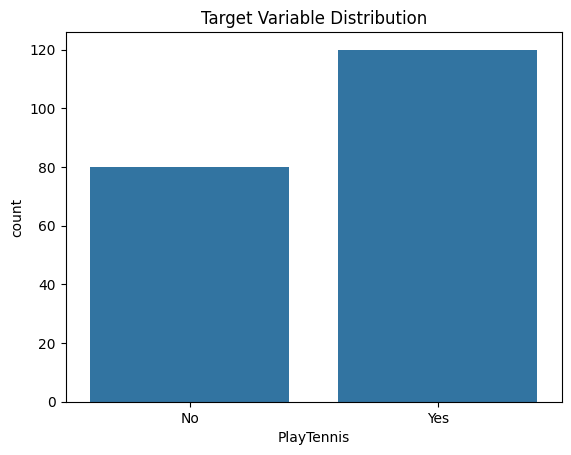

In [9]:
# target variable distribution
plt.figure()
sns.countplot(x='PlayTennis', data=df)
plt.title('Target Variable Distribution')

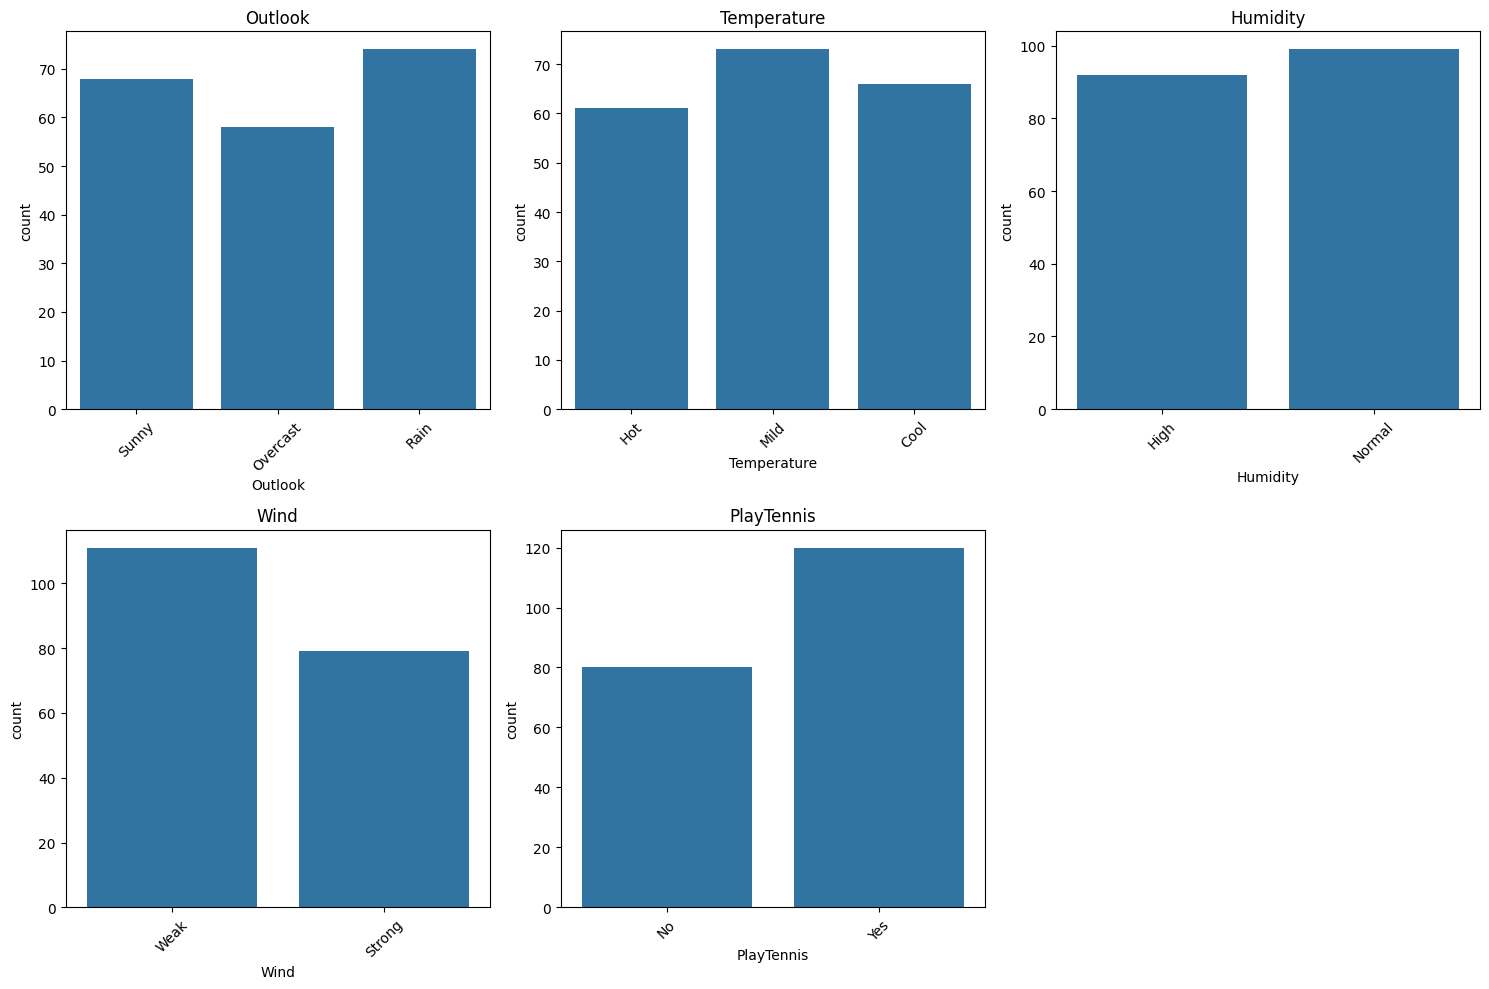

In [10]:
# categorical feature distribution
categorical_cols = df.columns

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=col, data=df)
    plt.title(f"{col}")
    plt.xticks(rotation=45)

plt.tight_layout()

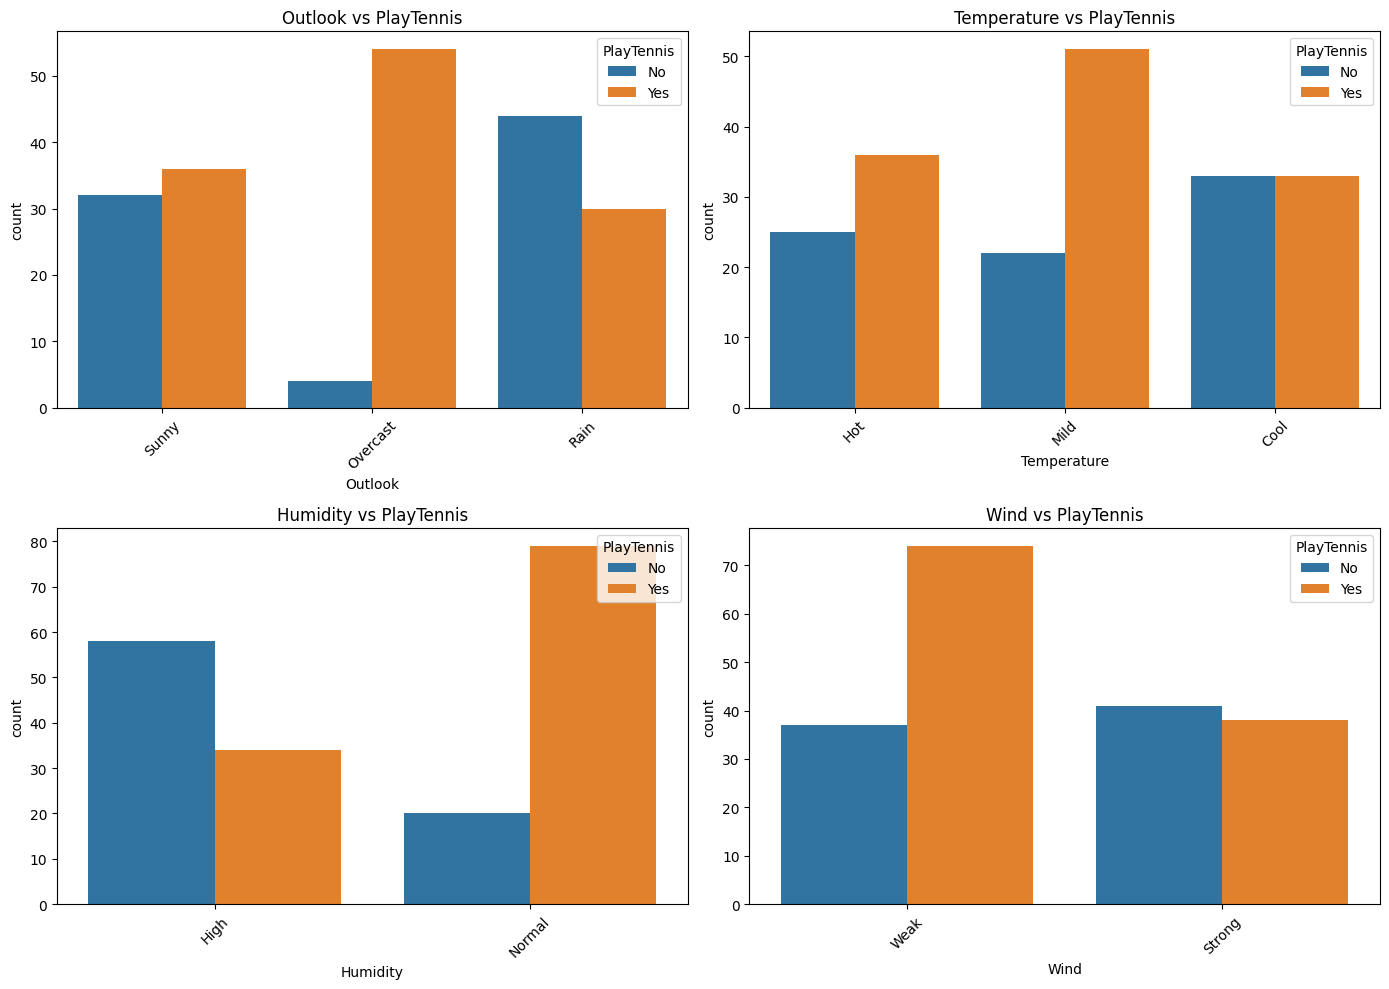

In [11]:
# feature and target analysis
cols = [col for col in df.columns if col != 'PlayTennis']

n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)
plt.figure(figsize=(14, 5 * n_rows))
for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=col, hue='PlayTennis', data=df)
    plt.title(f"{col} vs PlayTennis")
    plt.xticks(rotation=45)
    plt.legend(title='PlayTennis', loc='upper right')

plt.tight_layout()

In [12]:
# probability insight
for col in df.columns:
    if col != 'PlayTennis':
        print(f'{col} vs PlayTennis:')
        print(pd.crosstab(df[col], df['PlayTennis'], normalize='index'))

Outlook vs PlayTennis:
PlayTennis        No       Yes
Outlook                       
Overcast    0.068966  0.931034
Rain        0.594595  0.405405
Sunny       0.470588  0.529412
Temperature vs PlayTennis:
PlayTennis         No       Yes
Temperature                    
Cool         0.500000  0.500000
Hot          0.409836  0.590164
Mild         0.301370  0.698630
Humidity vs PlayTennis:
PlayTennis        No       Yes
Humidity                      
High        0.630435  0.369565
Normal      0.202020  0.797980
Wind vs PlayTennis:
PlayTennis        No       Yes
Wind                          
Strong      0.518987  0.481013
Weak        0.333333  0.666667


In [13]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

Outlook: ['Sunny' 'Overcast' 'Rain']
Temperature: ['Hot' 'Mild' 'Cool']
Humidity: ['High' 'Normal' nan]
Wind: ['Weak' 'Strong' nan]
PlayTennis: ['No' 'Yes']


### 🔎 Key Observations

- Most features are **categorical**, making Naive Bayes a strong candidate  
- Some missing values exist in *Humidity* and *Wind*  
- Certain feature categories show strong influence on the target  
- The dataset is simple but perfect for demonstrating probabilistic models  

💡 This structure aligns well with Naive Bayes assumptions.

---

## ⚙️ 4. Data Preprocessing

In [14]:
# null value check
df.isnull().sum()

Outlook         0
Temperature     0
Humidity        9
Wind           10
PlayTennis      0
dtype: int64

In [15]:
df[['Humidity', 'Wind']] = (df[['Humidity', 'Wind']].apply(lambda x: x.fillna(x.value_counts().idxmax())))

In [16]:
df.isnull().sum()

Outlook        0
Temperature    0
Humidity       0
Wind           0
PlayTennis     0
dtype: int64

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [18]:
# seperating features and target value
X = df.drop("PlayTennis", axis=1)
y = df["PlayTennis"]

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

---

## 🤖 5. Model Training - Naive Bayes

In [20]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [21]:
# using gaussian naive bayes 

model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

### Prediction

In [22]:
y_pred = model.predict(X_test) # predict

---

## 📈 6. Model Evaluation

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9
              precision    recall  f1-score   support

           0       1.00      0.75      0.86        16
           1       0.86      1.00      0.92        24

    accuracy                           0.90        40
   macro avg       0.93      0.88      0.89        40
weighted avg       0.91      0.90      0.90        40



In [24]:
# Predicting New Data

sample = [[
    le.fit_transform(["Sunny"])[0],
    le.fit_transform(["Cool"])[0],
    le.fit_transform(["High"])[0],
    le.fit_transform(["Strong"])[0]
]]

In [25]:
prediction = model.predict(sample)
print("Prediction:", "Yes" if prediction[0] == 1 else "No")

Prediction: Yes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


## 🎯 7. Conclusion

✔️ Built a simple and efficient Naive Bayes model  
✔️ Achieved solid baseline performance  
✔️ Demonstrated that simple models still matter  

---

### 🚀 What's Next?

- Try Logistic Regression / XGBoost  
- Perform feature engineering  
- Hyperparameter tuning  

---

⭐ **If you found this notebook helpful, consider upvoting!**

## 🙌 Feedback

If you have suggestions or improvements, feel free to comment!

Happy Learning! 🚀